<a href="https://colab.research.google.com/github/nicolastibata/MINE_4206_AML_202610/blob/main/labs/lab_4/MINE_4206_AML_202610_L4_S2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo AML](https://github.com/nicolastibata/MINE_4206_AML_202610/blob/main/docs/logo.jpg?raw=true)

# **Laboratorio 4 - Sesión 2: KMeans + Aglomerativo + DBSCAN**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Introducción de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación y Modelamiento](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- El conjunto de datos que utilizaremos se relaciona con la caracterización de vinos con base en atributos como el pH, la cantidad de dióxido de azufre, azúcar residual, entre otros. Este conocimiento puede resultar muy útil en la certificación de la calidad de una muestra de vino a partir de variables fisicoquímicas. Los datos han sido descargados a partir de este [enlace](https://archive.ics.uci.edu/dataset/186/wine+quality) y modificados para propósitos de este ejercicio. Es un caso ideal que permitirá ejemplificar todo el proceso.  
Cita: Cortez,Paulo, Cerdeira,A., Almeida,F., Matos,T., and Reis,J.. (2009). Wine Quality. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

**Objetivos**
1. Realizar la agrupación a través de algoritmos no supervisados como KMeans, DBSCAN y Aglomerativo.
2. Interpretar los resultados.

### **1. Introducción a los datos**

In [1]:
!pip install ydata-profiling -q
# Acceso a credenciales
import os
from google.colab import files
from google.colab import userdata

import pandas as pd
import numpy as np
import sys
import os
import os.path as osp
import joblib

from google.colab import files
from ydata_profiling import ProfileReport

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import silhouette_score, silhouette_samples, rand_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.1 MB/s eta 0:00:00


In [2]:
# data = pd.read_csv('Customer_Data.csv')
data = pd.read_csv('https://raw.githubusercontent.com/nicolastibata/MINE_4206_AML_202610/refs/heads/main/labs/lab_4/wine_quality_processed.csv')
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
dtypes: float64(11)
memory usage: 558.5 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03,6.497000e+03
mean,9.488212e-15,-5.302003e-15,-1.560635e-15,4.141096e-15,-4.525513e-15,-1.749836e-17,-5.077805e-15,1.672023e-13,-1.703356e-15,-2.628035e-15,3.682092e-14
std,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00,1.000077e+00
min,-2.680299e+00,-3.395338e+00,-1.888173e+00,-2.349915e+00,-1.711238e+00,-1.777419e+00,-1.650607e+00,-1.674397e+00,-1.675938e+00,-1.642268e+00,-3.855298e+00
25%,-3.504111e-01,-6.890711e-01,-1.159779e+00,-8.627730e-01,-8.446404e-01,-7.106407e-01,-1.006883e+00,-8.146318e-01,-8.113852e-01,-9.044219e-01,-2.307304e-01
50%,9.540250e-02,-5.776744e-02,3.498175e-01,6.123291e-01,-5.224995e-01,-4.087963e-01,-1.797901e-01,-4.417490e-01,-4.850368e-01,-2.176513e-01,2.387775e-01
75%,8.087332e-01,6.472573e-01,6.796426e-01,8.493480e-01,8.614753e-01,1.255585e+00,9.743695e-01,1.169419e+00,1.158006e+00,1.194099e+00,6.209495e-01
max,1.791988e+00,3.611734e+00,1.776875e+00,1.510558e+00,2.208806e+00,2.189364e+00,1.601905e+00,2.150203e+00,2.098036e+00,2.052117e+00,2.039935e+00


Observamos que todas nuestras variables son numéricas y con rangos muy similares, por lo tanto no usamos escaladores, ni algún tipo de tranformación a los datos.

### **2. Preparación y Modelamiento**

#### **Preparación**

#### **Modelamiento**

##### **Modelo K-Means**

Para definir nuestro modelo KMeans necesitamos establecer el hiperparámetro K, en este algoritmo lo conseguimos usando el método del codo y método de la silueta.

**Búsqueda del hiperparámetro K: Método del codo**

In [3]:
def buscar_modelo(k, semilla):
    print(f"Entrenando el modelo con k={k} y semilla={semilla}.")
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(data)

    return model.inertia_

In [4]:
candidatos = [9,22,33,42,50]
grupos = range(2,10)
distorsions = dict()

for semilla in candidatos:
    distorsions[semilla] = list()
    for k in grupos:
        inertia = buscar_modelo(k, semilla)
        distorsions[semilla].append(inertia)
        print("Score:",inertia)
        print('-'*50)

Entrenando el modelo con k=2 y semilla=9.
Score: 41553.1196488604
--------------------------------------------------
Entrenando el modelo con k=3 y semilla=9.
Score: 20566.786794563766
--------------------------------------------------
Entrenando el modelo con k=4 y semilla=9.
Score: 7719.853694706364
--------------------------------------------------
Entrenando el modelo con k=5 y semilla=9.
Score: 7053.364701015186
--------------------------------------------------
Entrenando el modelo con k=6 y semilla=9.
Score: 6701.942215362634
--------------------------------------------------
Entrenando el modelo con k=7 y semilla=9.
Score: 5876.742456710118
--------------------------------------------------
Entrenando el modelo con k=8 y semilla=9.
Score: 5806.405661828213
--------------------------------------------------
Entrenando el modelo con k=9 y semilla=9.
Score: 5602.987282402572
--------------------------------------------------
Entrenando el modelo con k=2 y semilla=22.
Score: 45781.

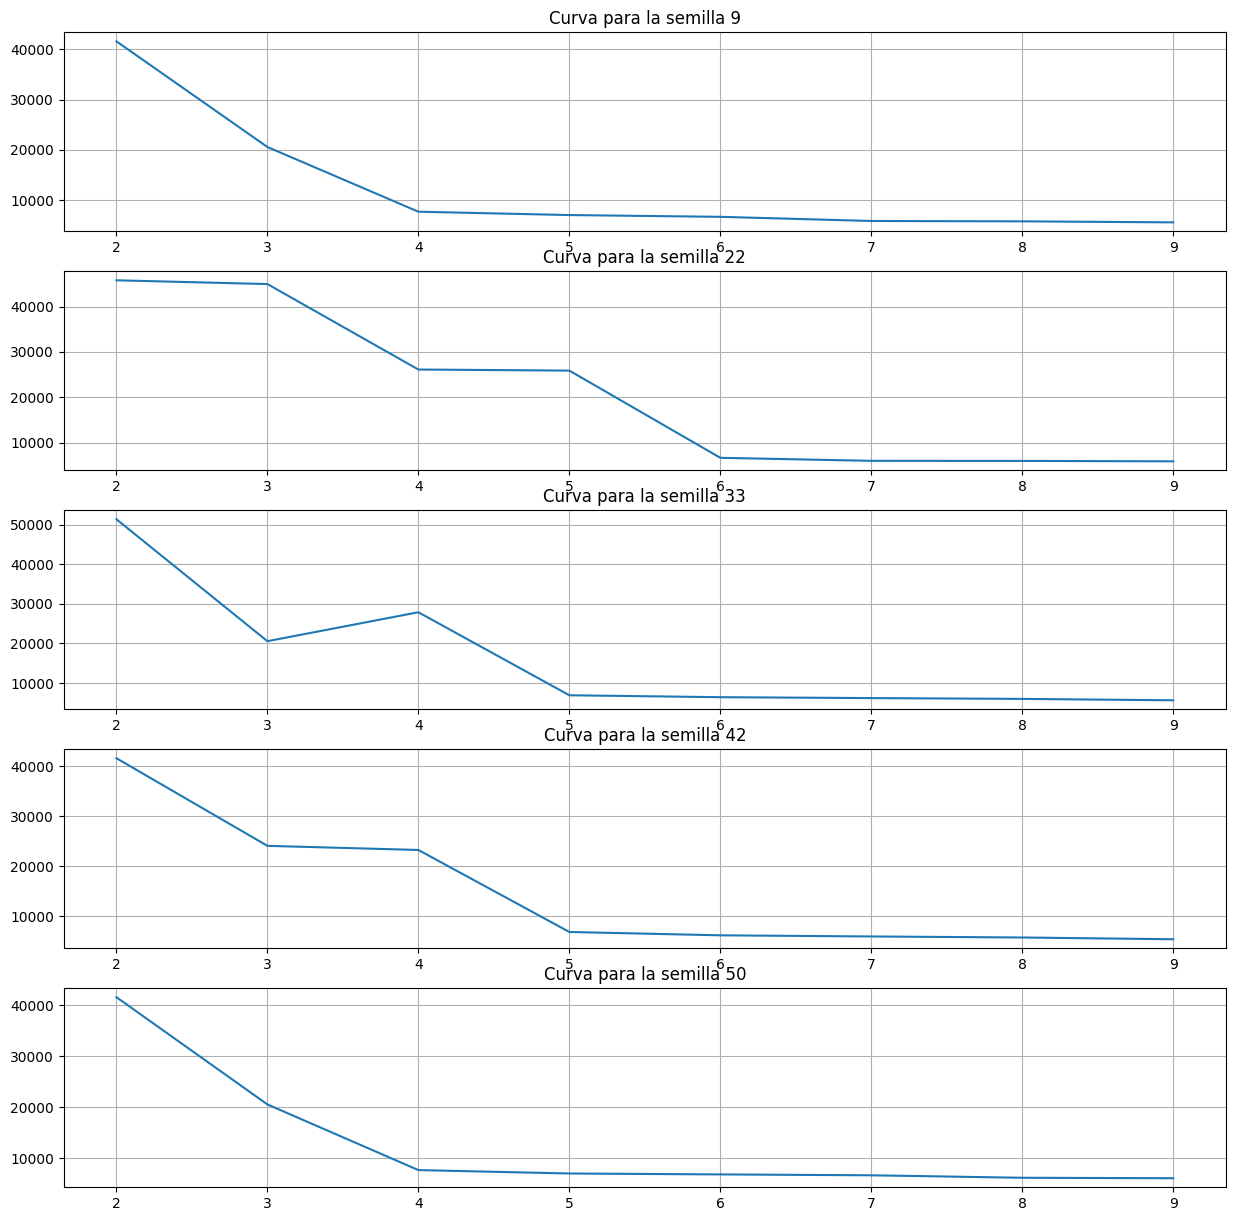

In [5]:
fig = plt.figure(figsize=(15, 15))

for i, sem in enumerate(candidatos):
    ax = plt.subplot(len(candidatos), 1, i + 1)
    plt.plot(grupos, distorsions[sem])
    plt.grid(True)
    plt.title(f'Curva para la semilla {sem}')
plt.show()

A pesar de que vemos una gran disminución en `k=4`, en algunos casos de las diferentes semillas nuestro valor óptimo es `k=5` ya que después de este es cuando se tiene un comportamiento aproximadamente lineal.

**Verifiquémoslo con el método de la silueta.**

**Búsqueda del hiperparámetro K: Método de la silueta**

In [6]:
def silhouette_plot(X, k_min=2, k_max=5):
    """
    Genera la gráfica con el coeficiente de la silueta

    Parametros:
    X : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    """
    scores = []
    for i in range(k_min, k_max+1):
        model_k = KMeans(n_clusters=i)
        # Entrenamos el modelo
        model_k.fit(X)
        # Almacenamos el coeficiente de la silueta
        score = silhouette_score(X, model_k.labels_)
        scores.append(score)

    # Graficamos los valores del coeficiente de la silueta
    plt.plot(range(k_min,k_max+1), scores, marker='o')
    plt.xlabel('Número de clústeres')
    plt.ylabel('Silhouette Score')
    plt.grid()
    plt.show()

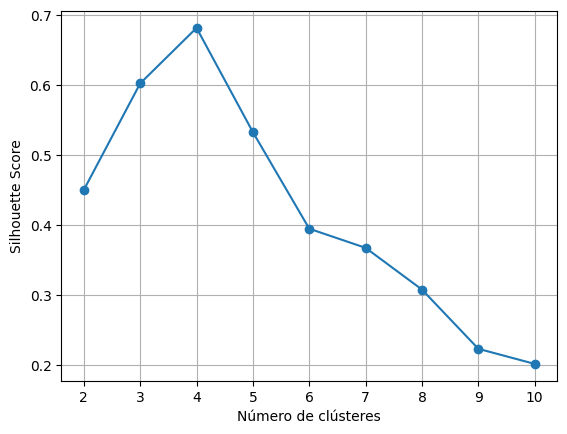

In [7]:
silhouette_plot(data, 2, 10)

Como podemos observar, el algoritmo kmeans retorna un valor máximo para el coeficiente de la silueta con 4 clústeres. Para obtener una descripción más detallada del coeficiente de la silueta para cada escenario, definiremos la función `silhouette_analysis()`:

In [8]:
def silhouette_analysis(X, k_min=2, k_max=5):
    """
    Genera gráficas con el coeficiente de la silueta para cada clúster y cada ejemplo

    Parametros:
    X : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    """
    for n_clusters in range(k_min, k_max+1):
        clusterer = KMeans(n_clusters)

        # Entrenamos el modelo
        cluster_labels = clusterer.fit_predict(X)
        # Obtenemos el coeficiente promedio
        silhouette_avg = silhouette_score(X, cluster_labels)
        # Obtenemos el coeficiente para cada ejemplo
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        # Inicializamos una figura
        fig = plt.figure(figsize = (18, 7))
        plt.xlim([-0.2, 1])
        plt.ylim([0, len(X) + (n_clusters + 1) * 10])

        y_lower = 10
        for i in range(n_clusters):
            # Obtenemos los valores del coeficiente para cada cluster
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            # Ordenamos los valores de mayor a menor
            ith_cluster_silhouette_values.sort()
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        plt.title(f"Método de la silueta (k={n_clusters})")
        plt.xlabel("Coeficiente")
        plt.ylabel("Clúster")

        # Incluimos el valor promedio
        plt.axvline(x=silhouette_avg, color="red", linestyle="--")
        plt.yticks([])
        plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()

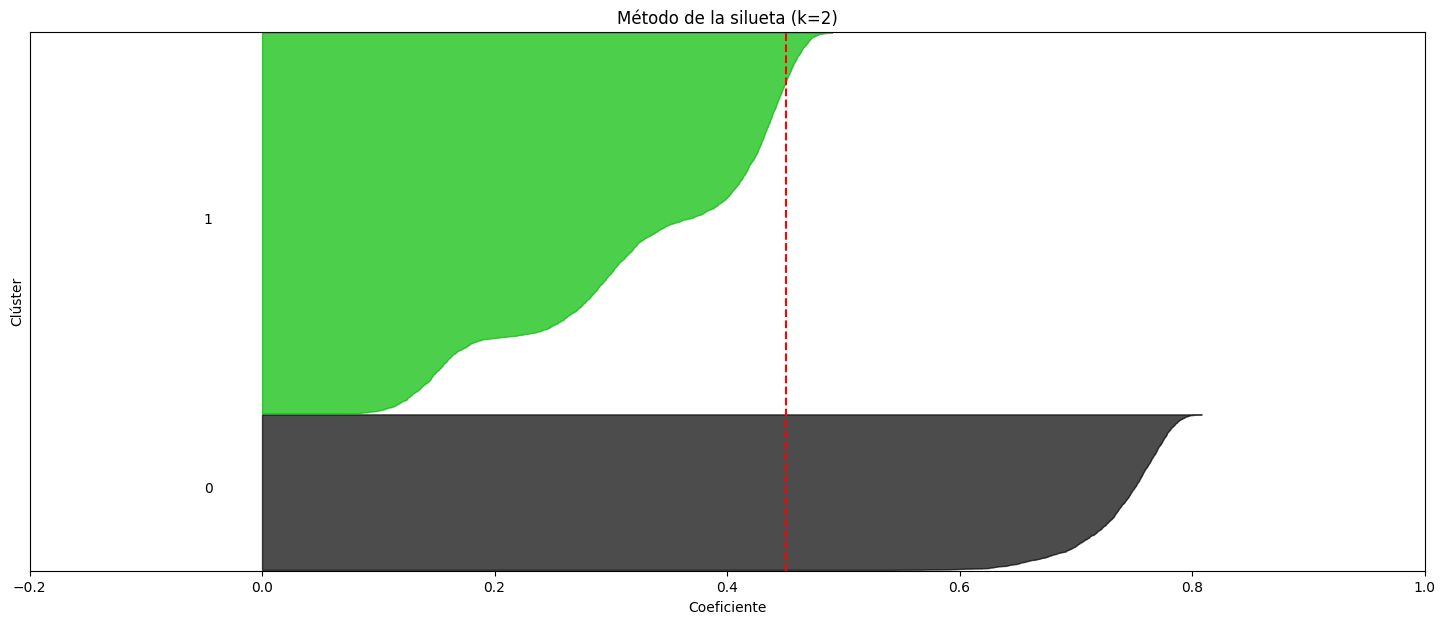

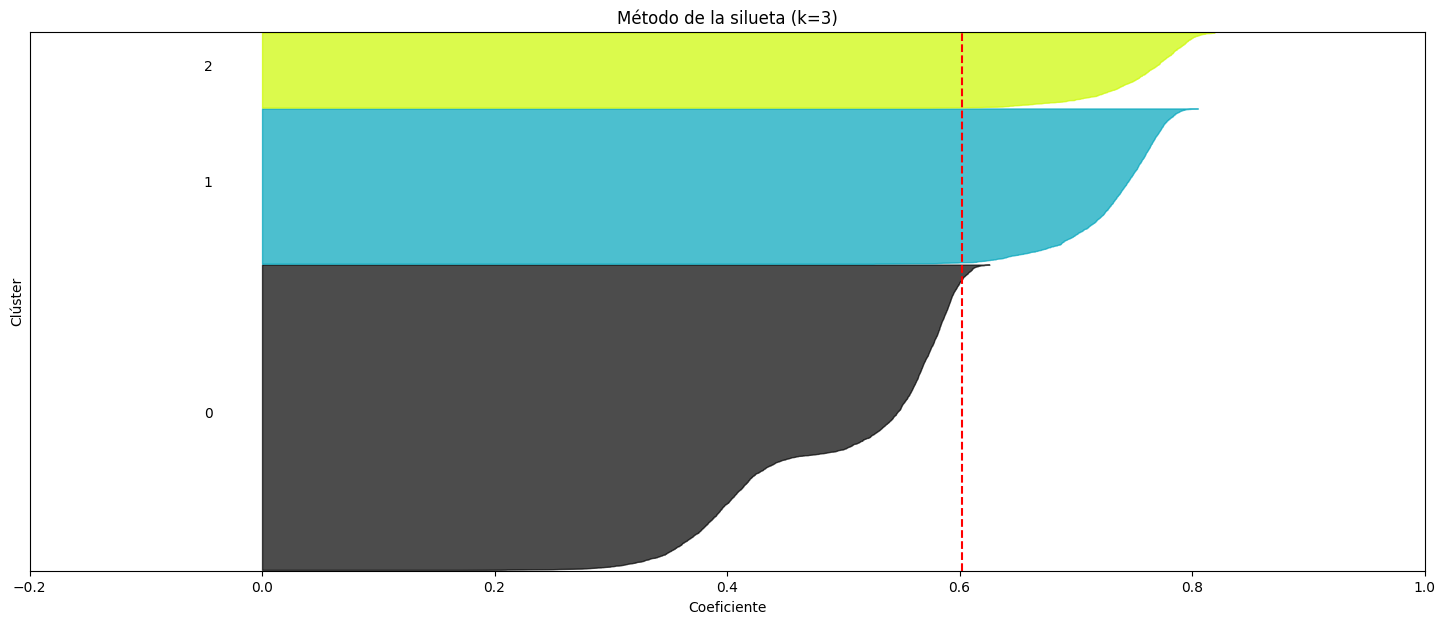

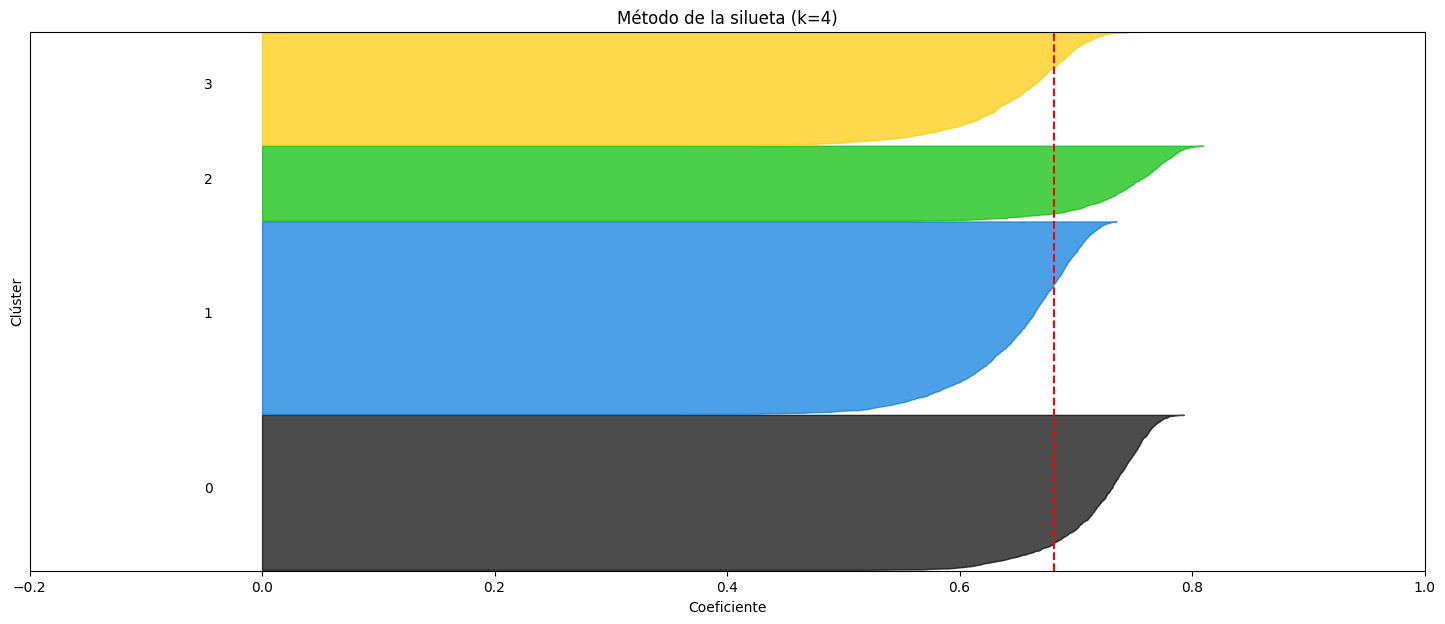

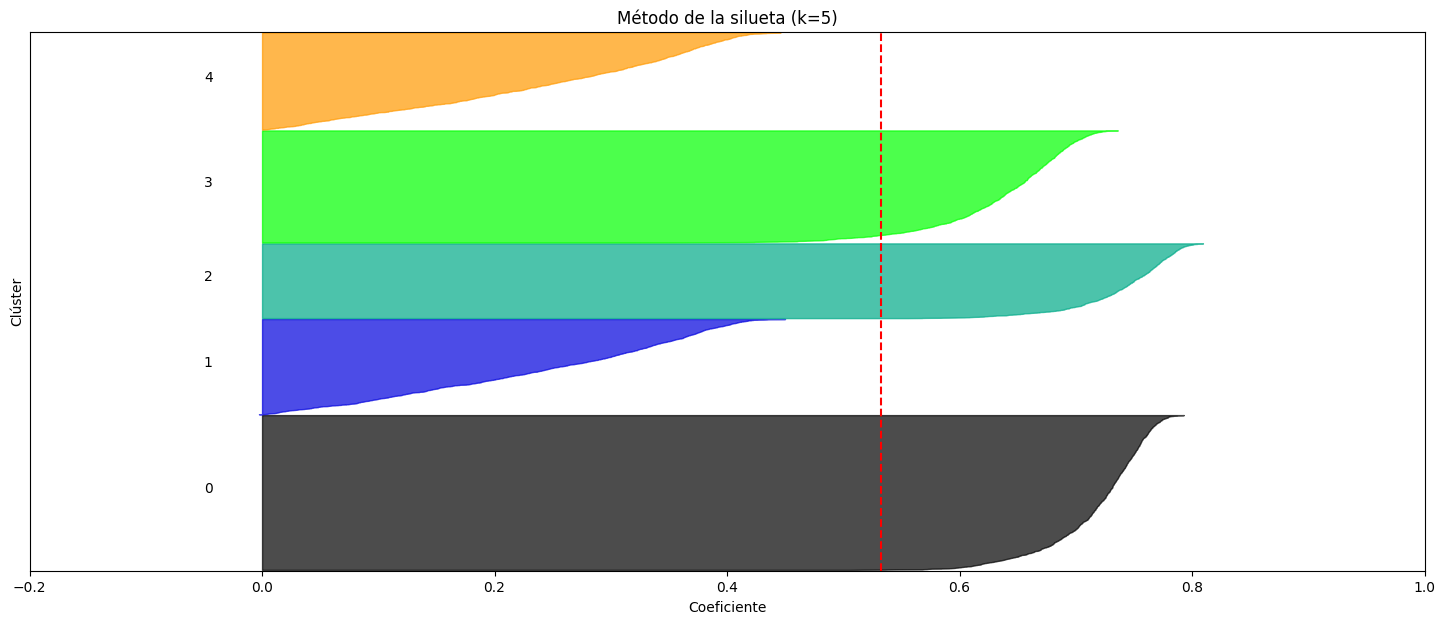

In [9]:
silhouette_analysis(data, 2, 5)

Como podemos observar, en `k=4` tenemos valores positivos superiores a 0.68 para todos los ejemplos de nuestro conjunto. Incluso, en `k=5` ya se empiezan a ver valores negativos muy sutiles para algunos clústeres, lo que indica que no están siendo asignados correctamente.

**Resultados**

In [35]:
model_KM = KMeans(n_clusters=4, random_state=50, init='random', n_init=1)
model_KM.fit(data)

KMeans(init='random', n_clusters=4, n_init=1, random_state=50)

In [42]:
final_df = data.copy()
final_df['Cluster'] = model_KM.predict(data)
final_df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Cluster
0,0.014686,-0.598414,0.687864,0.647556,-0.490277,-0.481295,-1.087387,-0.860845,1.023142,-1.216361,-0.204441,3
1,0.116950,-0.429483,0.489375,0.679115,-0.788505,-0.483734,-1.094311,-1.029712,1.386693,-0.791893,-0.234492,3
2,-0.136908,0.224380,1.273631,0.890364,-1.134886,-0.175259,0.759525,1.811517,-0.956226,-0.342054,0.377655,1
3,1.140204,0.623189,-1.306935,-0.696380,1.018252,1.564610,0.786791,-0.411051,-0.632910,1.301869,-0.044845,2
4,0.086776,-0.860876,0.688661,0.950283,-0.847040,-0.608213,-1.104763,-0.805384,1.672159,-1.114566,-0.189747,3
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,-0.457958,-1.342634,1.333921,0.951694,-1.100024,-0.707555,0.952948,1.616831,-0.439531,-0.376746,0.616034,1
6493,0.827474,-0.067910,-1.400654,-0.907656,0.648059,1.712415,1.039801,-0.403096,-0.943525,1.450743,0.047012,2
6494,1.402020,0.271908,-1.223636,-0.928997,0.952140,1.177667,1.077096,-0.785361,-1.119873,1.740129,1.138669,2
6495,0.066006,-0.781001,0.492280,0.835499,-0.620511,-0.230167,-1.066930,-0.807461,1.313426,-1.229324,-0.305540,3


([<matplotlib.axis.XTick at 0x7acf67ef2300>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

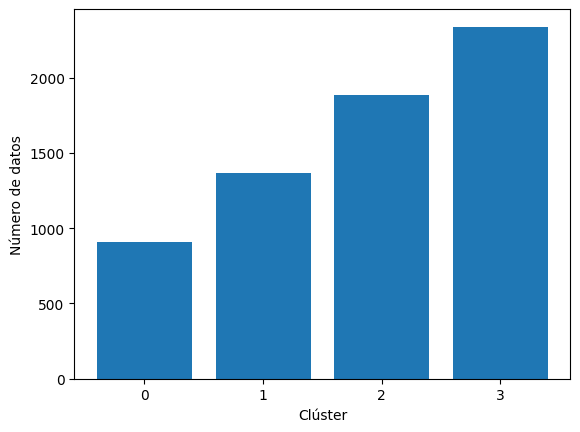

In [36]:
labels = model_KM.labels_
indexes, values = np.unique(labels, return_counts=True)
rects = plt.bar(indexes, values)
plt.xlabel('Clúster')
plt.ylabel('Número de datos')
plt.xticks(indexes)

Al ver la distribución nos damos cuenta que los vinos pertenecen más al último grupo, pero esto que significa? en qué se caracterizan? Necesitamos interpretar los centroides

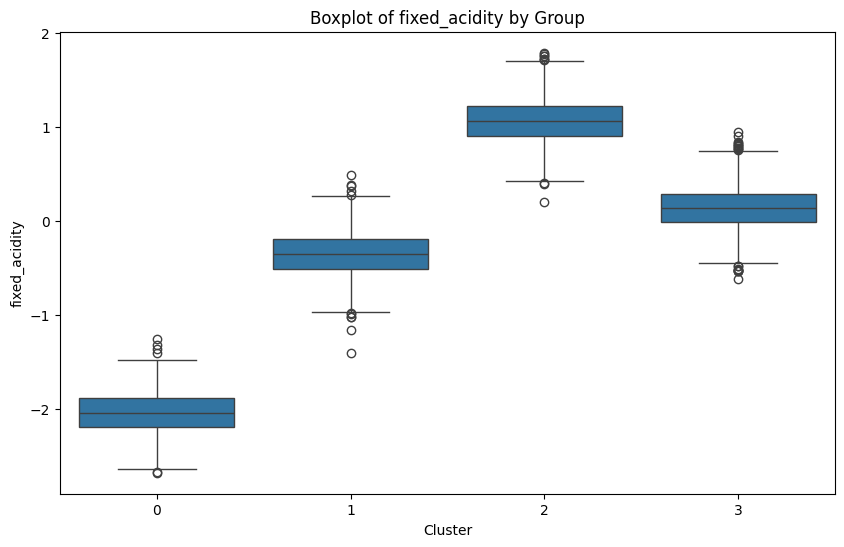

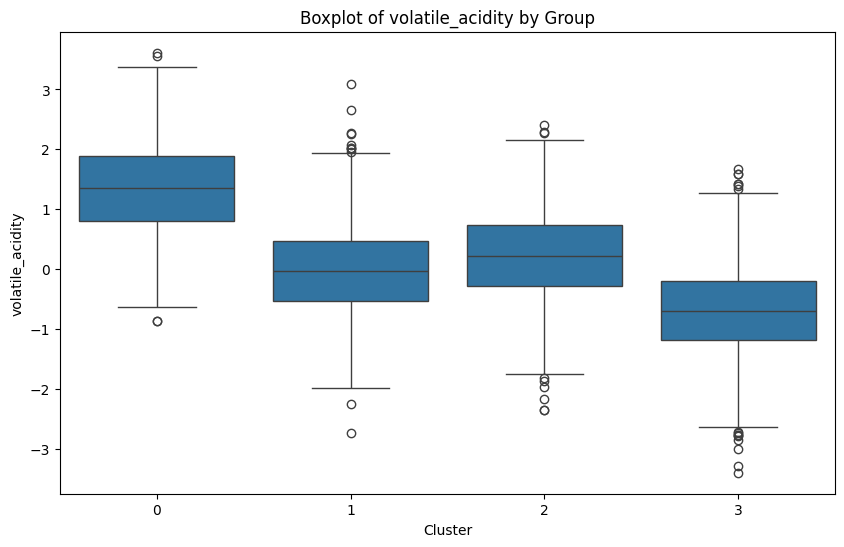

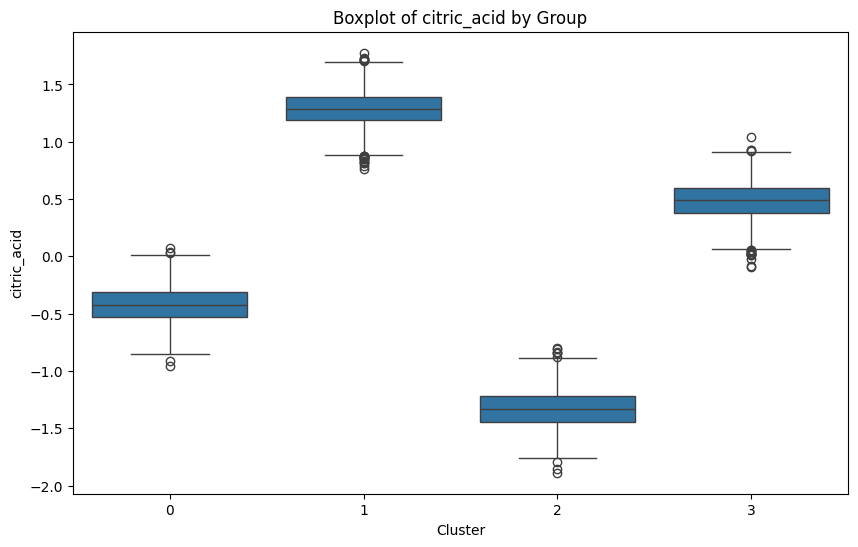

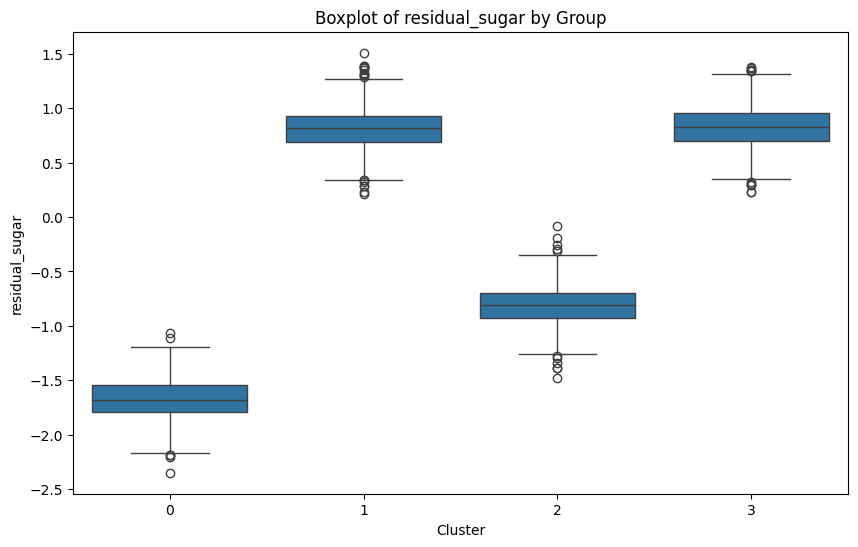

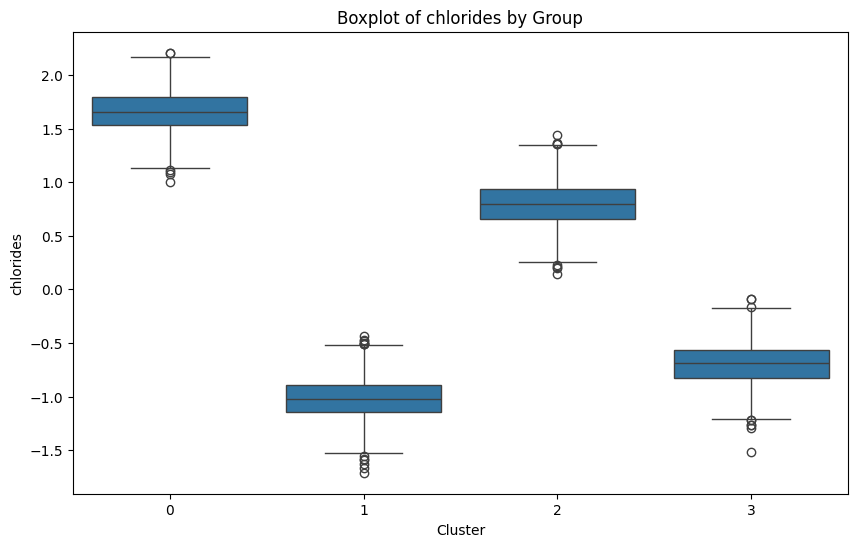

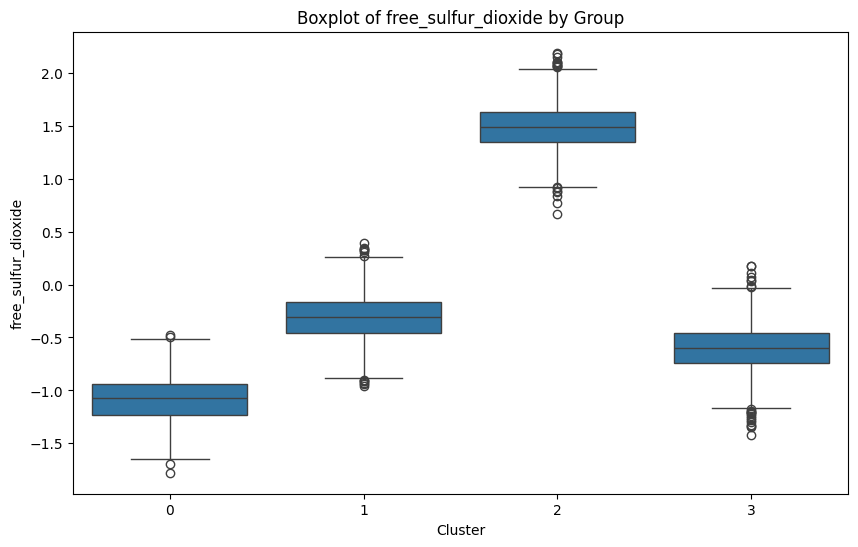

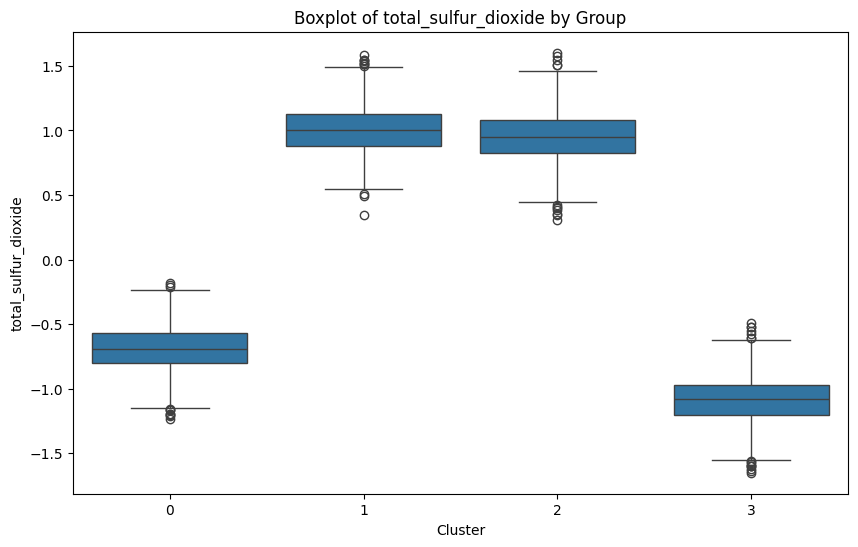

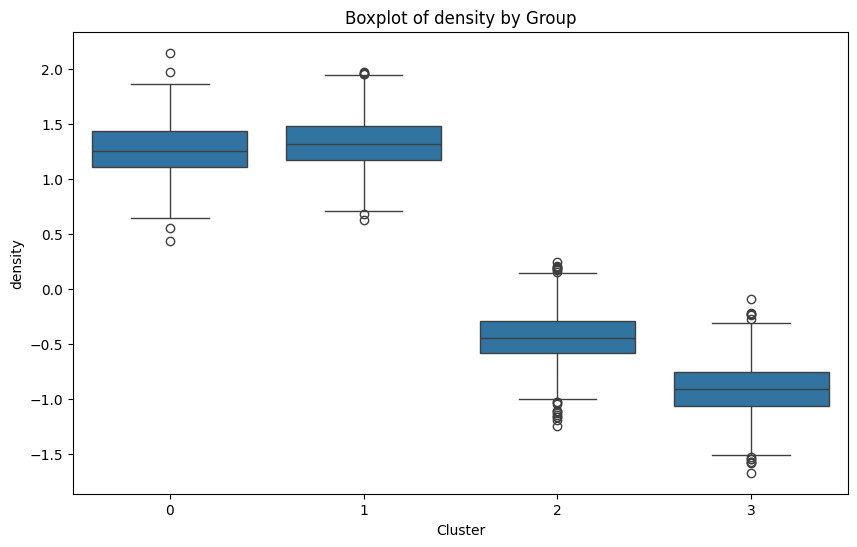

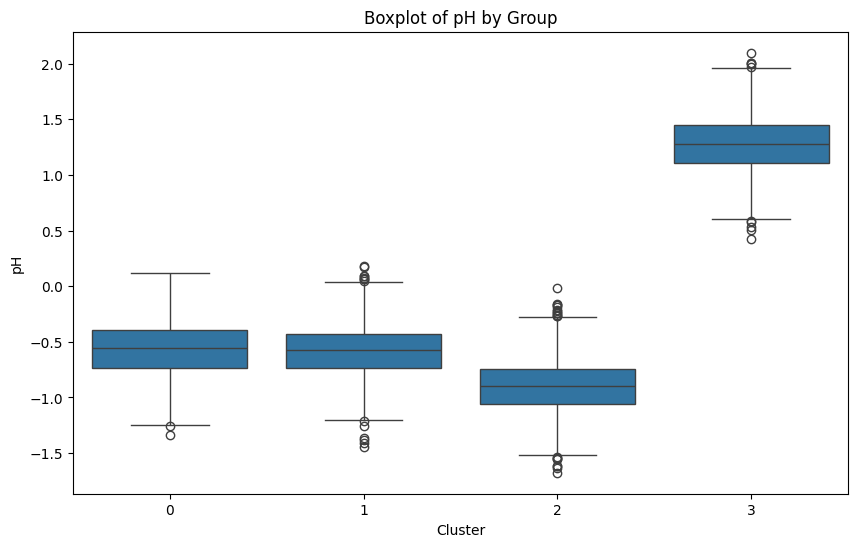

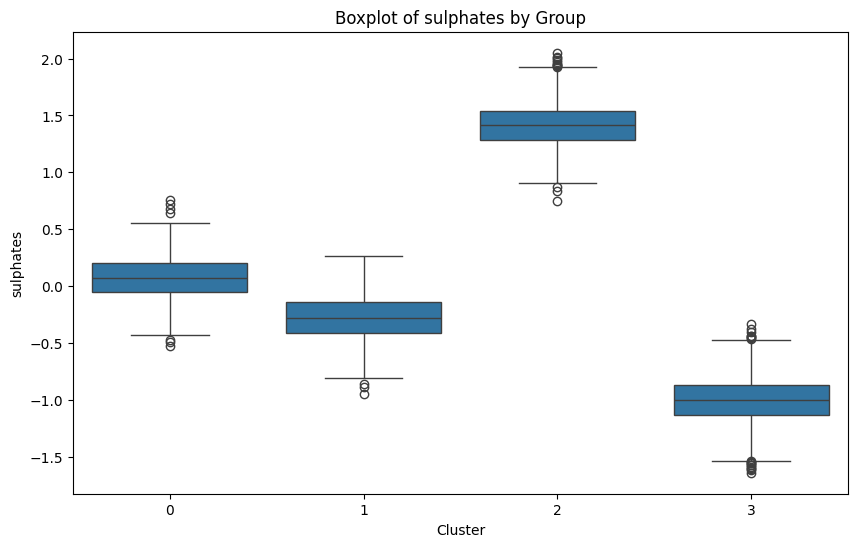

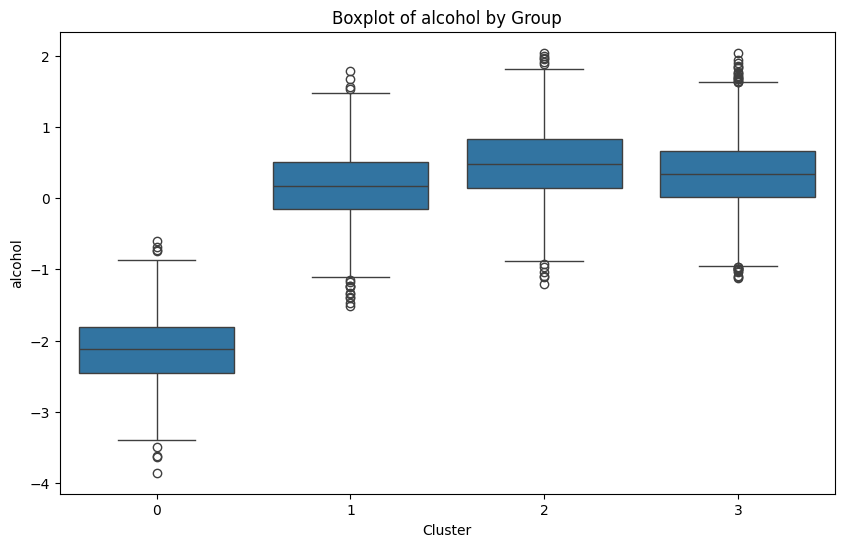

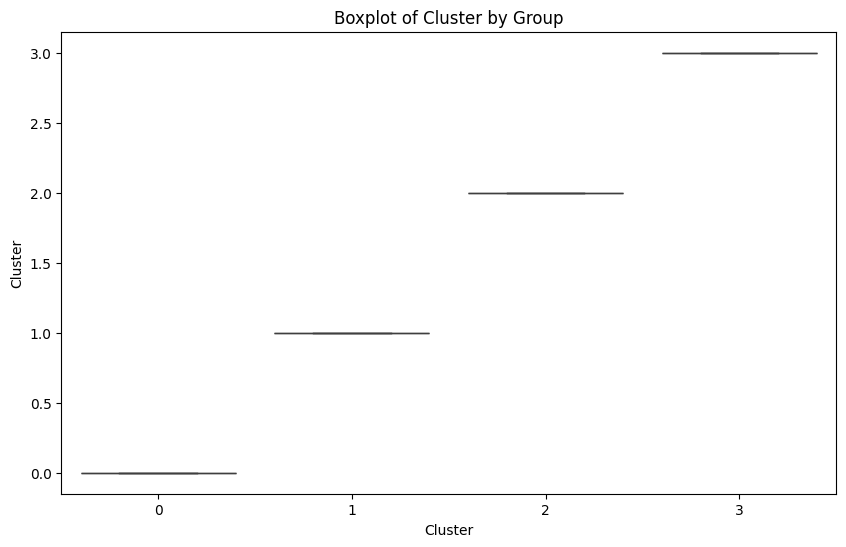

In [43]:
# veamos los boxplot
columns = final_df.columns
for column in columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=column, data=final_df)
    plt.title(f'Boxplot of {column} by Group')
    plt.show()

In [37]:
clusters = model_KM.cluster_centers_

info_clusters = pd.DataFrame(clusters, index=[f"Grupo {i+1}" for i in range(len(clusters))], columns=data.columns)
info_clusters

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
Grupo 1,-2.039566,1.352269,-0.422846,-1.669951,1.659522,-1.082532,-0.694516,1.269350,-0.565529,0.072332,-2.131081
Grupo 2,-0.353848,-0.024005,1.288322,0.812990,-1.022286,-0.306528,1.007019,1.323824,-0.580429,-0.281343,0.175598
Grupo 3,1.067722,0.220141,-1.332504,-0.810863,0.797334,1.486911,0.953409,-0.439753,-0.896566,1.415150,0.477336
Grupo 4,0.139831,-0.689427,0.486514,0.828732,-0.691725,-0.597748,-1.084988,-0.911634,1.280662,-1.003939,0.342226


- **Clúster 0:** Este segmento se caracteriza por ser vinos muy altos en cloruros (salinidad) y con gran volatilidad en la acidez. Sin embargo tiene el menor nivel de alcohol, menor nivel de acidez fija y de azucar residual. Vinos muy salinos y con poco cuerpo alcohólico.

- **Clúster 1:** Este segmento de vinos presenta el nivel más alto en ácido cítrico y niveles altos en azúcar residual, es el más bajo en cloruros (poca salinidad) y tiene un pH bajo. Por lo tanto pueden ser vinos frutales y dulces por su estructura.

- **Clúster 2:** Este segmento se caracteriza por tener los niveles más altos de sulfatos, dióxido de azufre libre, alcohol y acidez fija. Por lo tanto es extremadamente bajo en ácido cítrico y con el pH más bajo de todos. Son vinos con mucha estructura y alta protección (sulfitos).

- **Clúster 3:** Este grupo tiene el pH más alto (menos ácido) y niveles considerables de azúcar residual. Tiene los niveles más bajos en sulfatos, densidad y acidez volatil. Esto quiere decir que son vinos ligeros, con baja presencia de conservantes químicos, menos ácidos y con bien nivel de alcohol, suelen ser vinos más maduros.

##### **Modelo Aglomerativo**

Para el modelo aglomerativo realizamos el método de la silueta para la búsqueda del hiperparámetro K y luego realizamos la generación del dendograma.

> En este caso es importante agregar `linkage` y el cambio a nuestro modelo aglomerativo en la función.

In [34]:
def silhouette_plot(X, k_min=2, k_max=5, linkage='ward'):
    """
    Genera la gráfica con el coeficiente de la silueta

    Parametros:
    X : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    linkage : str
        Criterio de unión. Parámetro de AgglomerativeClustering()
    """
    scores = []
    for i in range(k_min, k_max+1):
        model_k = AgglomerativeClustering(n_clusters=i, linkage=linkage)
        # Entrenamos el modelo
        model_k.fit(X)
        # Almacenamos el coeficiente de la silueta
        score = silhouette_score(X, model_k.labels_)
        scores.append(score)

    # Graficamos los valores del coeficiente de la silueta
    plt.plot(range(k_min,k_max+1), scores, marker='o')
    plt.xlabel('Número de clústeres')
    plt.ylabel('Silhouette Score')
    plt.grid()
    plt.show()

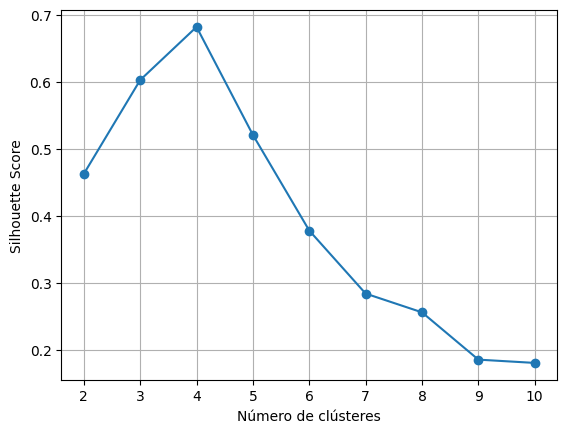

In [35]:
silhouette_plot(data, 2, 10)

Mismo resultado de que nuestro mejor K es 4

In [36]:
def silhouette_analysis(X, k_min=2, k_max=5, linkage='ward'):
    """
    Genera gráficas con el coeficiente de la silueta para cada clúster y cada ejemplo

    Parametros:
    X : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    linkage : str
        Criterio de unión. Parámetro de AgglomerativeClustering()
    """
    for n_clusters in range(k_min, k_max+1):
        clusterer = AgglomerativeClustering(n_clusters, linkage=linkage)

        # Entrenamos el modelo
        cluster_labels = clusterer.fit_predict(X)
        # Obtenemos el coeficiente promedio
        silhouette_avg = silhouette_score(X, cluster_labels)
        # Obtenemos el coeficiente para cada ejemplo
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        # Inicializamos una figura
        fig = plt.figure(figsize = (18, 7))
        plt.xlim([-0.2, 1])
        plt.ylim([0, len(X) + (n_clusters + 1) * 10])

        y_lower = 10
        for i in range(n_clusters):
            # Obtenemos los valores del coeficiente para cada cluster
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            # Ordenamos los valores de mayor a menor
            ith_cluster_silhouette_values.sort()
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        plt.title(f"Método de la silueta (k={n_clusters})")
        plt.xlabel("Coeficiente")
        plt.ylabel("Clúster")

        # Incluimos el valor promedio
        plt.axvline(x=silhouette_avg, color="red", linestyle="--")
        plt.yticks([])
        plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()

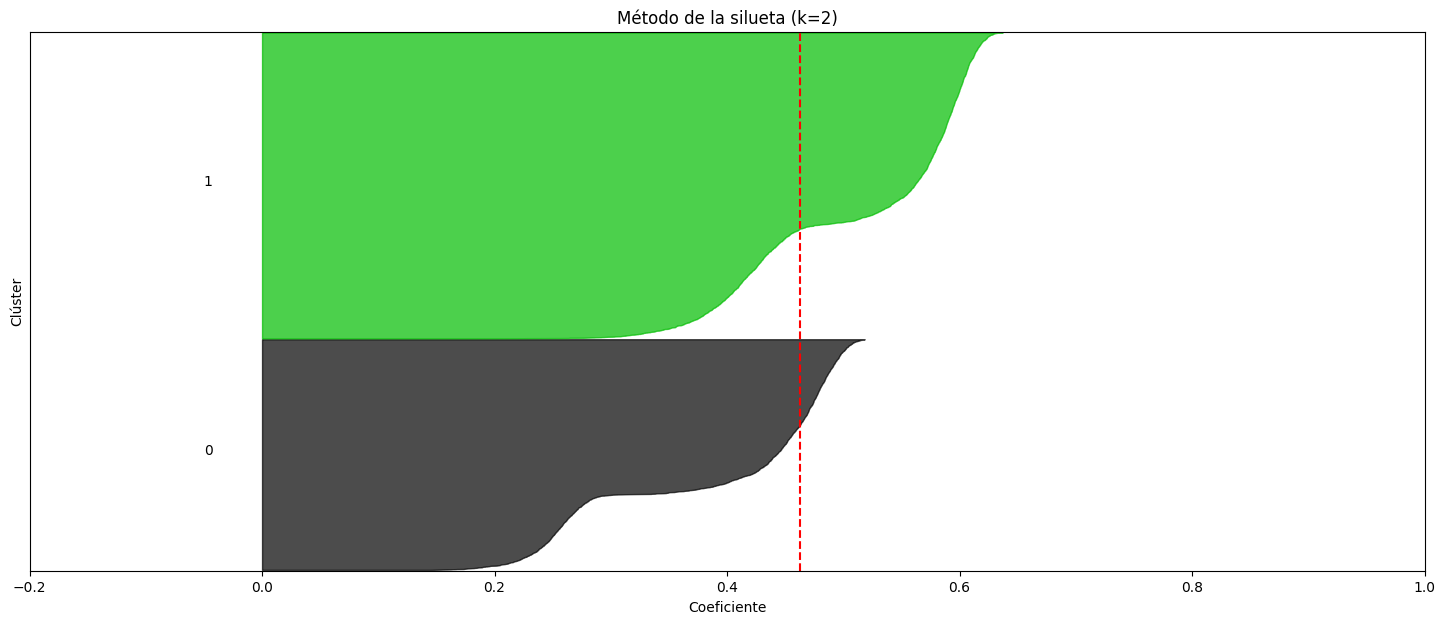

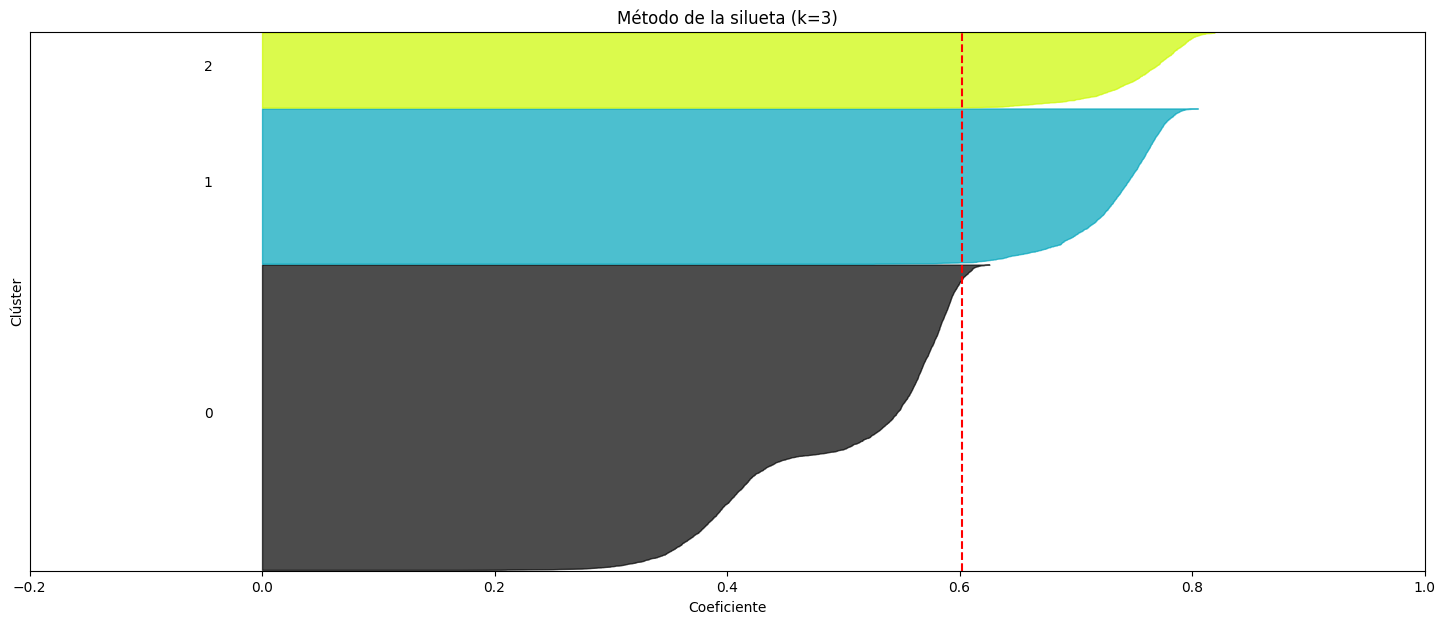

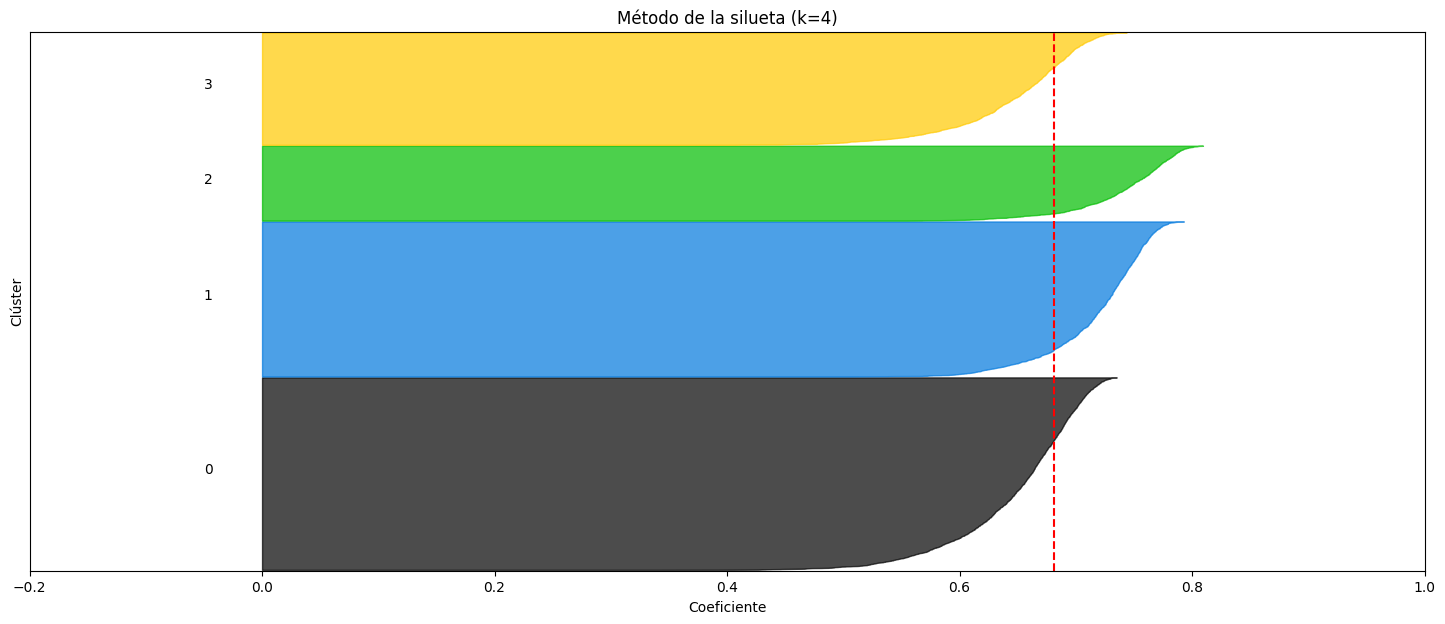

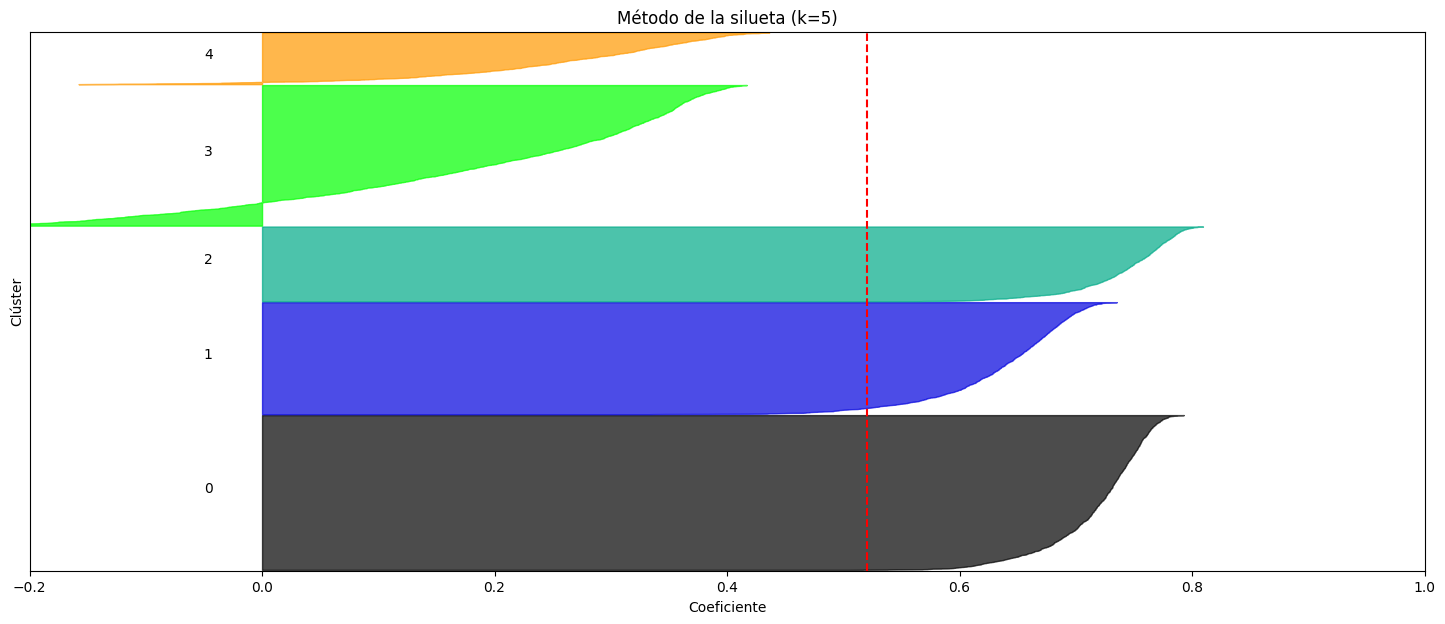

In [37]:
silhouette_analysis(data, 2, 5)

Mismo score de 0.68 cuando es k=4

**Generación del dendograma**

El dendrograma, o diagrama de árbol, nos permite visualizar la jerarquía de las uniones realizadas por el algoritmo aglomerativo en función de la distancia. Ten en cuenta que, al usar `linkage=ward`, estamos utilizando la distancia euclidiana para realizar las comparaciones entre parejas de clústeres. Primero usaremos la función `linkage()` para aplicar el algoritmo aglomerativo a nuestro conjunto de datos:

In [40]:
data_lnk = linkage(data, 'ward', 'euclidean')
data_lnk

array([[6.47000000e+02, 5.55600000e+03, 1.57962212e-01, 2.00000000e+00],
       [8.39000000e+02, 4.08000000e+03, 1.84531841e-01, 2.00000000e+00],
       [9.91000000e+02, 2.96700000e+03, 1.91526161e-01, 2.00000000e+00],
       ...,
       [1.29870000e+04, 1.29890000e+04, 1.60293063e+02, 3.70300000e+03],
       [1.29850000e+04, 1.29880000e+04, 2.04872316e+02, 2.79400000e+03],
       [1.29900000e+04, 1.29910000e+04, 2.44597140e+02, 6.49700000e+03]])

El resultado de aplicar la función `linkage()` es una matriz de uniones, donde cada fila representa una fusión de dos clústeres (en total N-1, hasta llegar a un único clúster). Se tienen cuatro columnas, las dos primeras muestran los índices de los ejemplos tomados para aplicar el criterio de unión, la tercera muestra la distancia entre ellos, y la última muestra el número de ejemplos en el clúster resultante:

In [41]:
pd.DataFrame(data_lnk, columns=['Índice 1', 'Índice 2', 'Distancia', '# Ejemplos en clúster'])

,Índice 1,Índice 2,Distancia,# Ejemplos en clúster
0,647.0,5556.0,0.157962,2.0
1,839.0,4080.0,0.184532,2.0
2,991.0,2967.0,0.191526,2.0
3,2562.0,6411.0,0.208076,2.0
4,4070.0,5767.0,0.217690,2.0
...,...,...,...,...
6491,12979.0,12983.0,34.987858,1884.0
6492,12978.0,12986.0,35.553993,2339.0
6493,12987.0,12989.0,160.293063,3703.0
6494,12985.0,12988.0,204.872316,2794.0


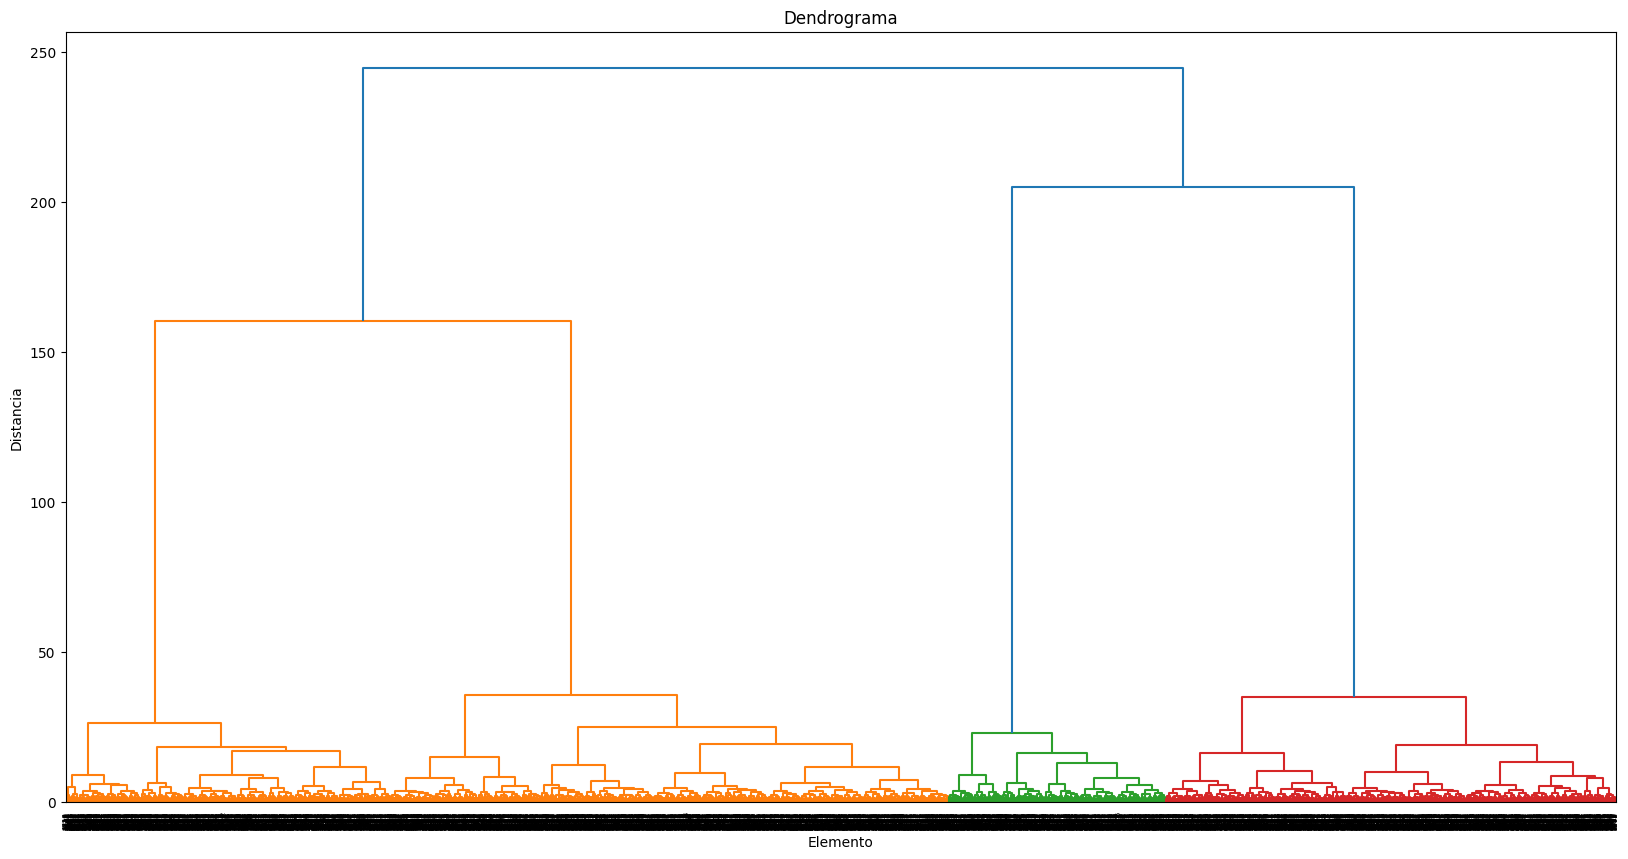

In [42]:
plt.figure(figsize=(20, 10))
dendrogram(data_lnk)
plt.title('Dendrograma')
plt.xlabel('Elemento')
plt.ylabel('Distancia')
plt.show()

Como puedes observar, se inicia con N clústeres y se agrega un nodo padre para representar cada unión entre parejas. El eje _y_ nos muestra la distancia entre clústeres, por lo que lineas más largas representan uniones realizadas con clústeres más separados. Específicamente para nuestro conjunto de datos, hay una gran distancia al pasar de cuatro clústeres a dos, por lo que tiene sentido que el mejor valor de _k_ sea 4. Por otra parte, la línea horizontal más larga que no corta una línea horizontal nos indica que efectivamente el número óptimo de grupos es 4.

In [55]:
model_AG = AgglomerativeClustering(n_clusters=4)
clusters = model_AG.fit_predict(data)
clusters

array([0, 0, 3, ..., 1, 0, 2])

([<matplotlib.axis.XTick at 0x7966c29b20c0>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

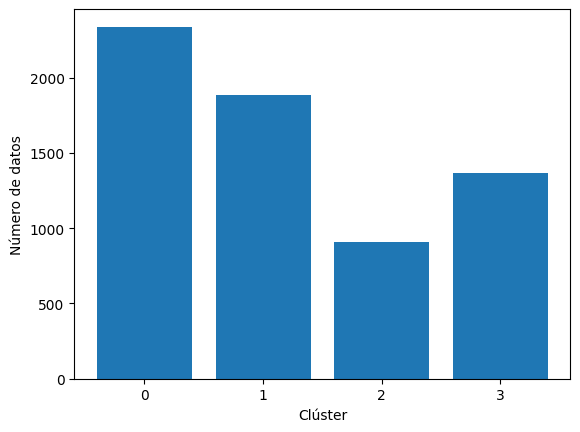

In [56]:
labels = model_AG.labels_
indexes, values = np.unique(labels, return_counts=True)

rects = plt.bar(indexes, values)
plt.xlabel('Clúster')
plt.ylabel('Número de datos')
plt.xticks(indexes)

El modelo aglomerativo no contiene centroides como el KMeans, pero al realizar `fit_predict` nos genera el cluster y con base en los grupos generamos los promedios para poder interpretar cada uno de los grupos.

In [57]:
df_ag = pd.DataFrame(data, columns=data.columns)
df_ag['cluster'] = clusters
summary_df_ag = df_ag.groupby('cluster').mean()
summary_df_ag

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,0.139831,-0.689427,0.486514,0.828732,-0.691725,-0.597748,-1.084988,-0.911634,1.280662,-1.003939,0.342226
1,1.067722,0.220141,-1.332504,-0.810863,0.797334,1.486911,0.953409,-0.439753,-0.896566,1.415150,0.477336
2,-2.039566,1.352269,-0.422846,-1.669951,1.659522,-1.082532,-0.694516,1.269350,-0.565529,0.072332,-2.131081
3,-0.353848,-0.024005,1.288322,0.812990,-1.022286,-0.306528,1.007019,1.323824,-0.580429,-0.281343,0.175598


Si nos fijamos bien son los mismos resultados de las agrupaciones con KMeans pero en orden distinto y coeficientes ligeramente distintos.

##### **Modelo DBSCAN**

DBSCAN tiene dos hiperparámetros que deben ser definidos antes del entrenamiento: épsilon y el mínimo de puntos en la vecindad. Estos hiperparámetros están representados por los parámetros `eps` y `min_samples` de la clase `DBSCAN()`. Pero ¿cómo podemos seleccionar el mejor valor para cada uno? Una de las formas más sencillas es mediante un Grid-Search o búsqueda exhaustiva, en la que probaremos todas las combinaciones de valores, entrenando un modelo por cada una:

In [58]:
# Definimos el espacio de búsqueda con dos listas:
# Valores de Épsilon
eps_list = [0.5, 1, 1.5, 2, 2.5, 3]
# Valores del mínimo de puntos
min_samples_list = [3, 5, 7, 10]

In [59]:
def silhouette_scores_DBSCAN(X, eps_list, min_samples_list, metric):
    """
    Calcula el coeficiente de la silueta para todas las combinaciones de (eps, min_samples) usando DBSCAN

    Parametros:
    X : np.array
        El arreglo con los datos
    eps_list : list
        Lista de valores para el hiperparámetro épsilon
    min_samples_list : list
        Lista de valores para el hiperparámetro min_samples
    metric : str
        Métrica de distancia a utilizar
    """
    # Vamos a almacenar cada combinación, el coeficiente de la silueta y el número de clústeres
    scores, eps_scores, min_samples_scores, num_clusters = [], [], [], []
    # Definimos la búsqueda exhaustiva con dos ciclos
    # El primero recorre todos los valores de épsilon
    for i in range(len(eps_list)):
        # Y el segundo recorre todos los valores de min_samples
        for j in range(len(min_samples_list)):
            # Obtenemos los valores actuales para los hiperparámetros
            eps_i = eps_list[i]
            min_samples_j = min_samples_list[j]
            eps_scores.append(eps_i)
            min_samples_scores.append(min_samples_j)
            # Definimos un modelo de DBSCAN con los valores actuales
            model_ij = DBSCAN(eps=eps_i, min_samples=min_samples_j, metric=metric, n_jobs=-1)
            # Entrenamos el modelo
            model_ij.fit(X)
            labels_ij = model_ij.labels_
            num_clusters_ij = len(set(labels_ij))
            num_clusters.append(num_clusters_ij)
            # Almacenamos el coeficiente de la silueta
            # Si tenemos un número de clústeres mayor a 1, el coeficiente de la silueta está definido
            if num_clusters_ij > 1:
                score = silhouette_score(X, labels_ij)
                scores.append(score)
            # Si DBSCAN retorna un solo clúster, el coeficiente de la silueta no está definido
            else:
                scores.append(-1)
    # Construimos un DataFrame para retornar el resultado
    scores_df = pd.DataFrame({
        'epsilon': eps_scores,
        'min_samples': min_samples_scores,
        'score': scores,
        'num_clusters': num_clusters
    })
    # Retornamos el DataFrame ordenado por el coeficiente promedio
    return scores_df.sort_values('score', ascending=False)

In [60]:
silhouette_scores = silhouette_scores_DBSCAN(data, eps_list, min_samples_list, 'euclidean')
silhouette_scores

,epsilon,min_samples,score,num_clusters
15,2.0,10,0.681632,4
14,2.0,7,0.681632,4
13,2.0,5,0.681632,4
12,2.0,3,0.681632,4
11,1.5,10,0.681632,4
10,1.5,7,0.681632,4
9,1.5,5,0.681632,4
8,1.5,3,0.681632,4
16,2.5,3,0.681632,4
17,2.5,5,0.681632,4


Como podemos observar, DBSCAN retorna un valor máximo para el coeficiente de la silueta de 0.68, definiendo 4 clústeres (igual que KMeans y aglomerativo). Si revisamos el valor de `eps`, podemos observar que el rango de valores óptimo se encuentra en [1.5, 2.5], mientras que `min_samples` puede tomar cualquier valor dentro del espacio de búsqueda que definimos inicialmente.

Para obtener una descripción más detallada del coeficiente de la silueta para cada escenario, modificaremos la función `silhouette_analysis()` para DBSCAN, es decir agregamos `eps` y `min_samples` dentro de los gráficos.

In [61]:
def silhouette_analysis(X, silhouette_scores, metric):
    """
    Genera gráficas con el coeficiente de la silueta para cada clúster y cada ejemplo

    Parametros:
    X : np.array
        El arreglo con los datos
    silhouette_scores : pd.DataFrame
        El DataFrame retornado por la función silhouette_scores_DBSCAN()
    metric : str
        Métrica de distancia a utilizar
    """
    for i in range(len(silhouette_scores)):
        eps_i, min_samples_i, score_i, clusters_i = silhouette_scores.iloc[i]
        # Definimos el modelo
        clusterer = DBSCAN(eps=eps_i, min_samples=int(min_samples_i), metric=metric, n_jobs=-1)
        # Entrenamos el modelo
        cluster_labels = clusterer.fit_predict(X)
        # Obtenemos el coeficiente para cada ejemplo
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        # Inicializamos una figura
        fig = plt.figure(figsize = (18, 7))
        plt.xlim([-0.2, 1])
        plt.ylim([0, len(X) + (int(clusters_i) + 1) * 10])

        y_lower = 10
        for j in set(cluster_labels):
            # Obtenemos los valores del coeficiente para cada clúster
            jth_cluster_silhouette_values = sample_silhouette_values[cluster_labels == j]
            # Ordenamos los valores de mayor a menor
            jth_cluster_silhouette_values.sort()
            size_cluster_j = jth_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_j

            color = cm.nipy_spectral(float(j) / int(clusters_i))
            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                jth_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            plt.text(-0.05, y_lower + 0.5 * size_cluster_j, str(j))
            y_lower = y_upper + 10

        plt.title(f"Método de la silueta (eps={eps_i}, min_samples={min_samples_i}, k={int(clusters_i)})")
        plt.xlabel("Coeficiente")
        plt.ylabel("Clúster")

        # Incluimos el valor promedio
        plt.axvline(x=score_i, color="red", linestyle="--")
        plt.yticks([])
        plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()

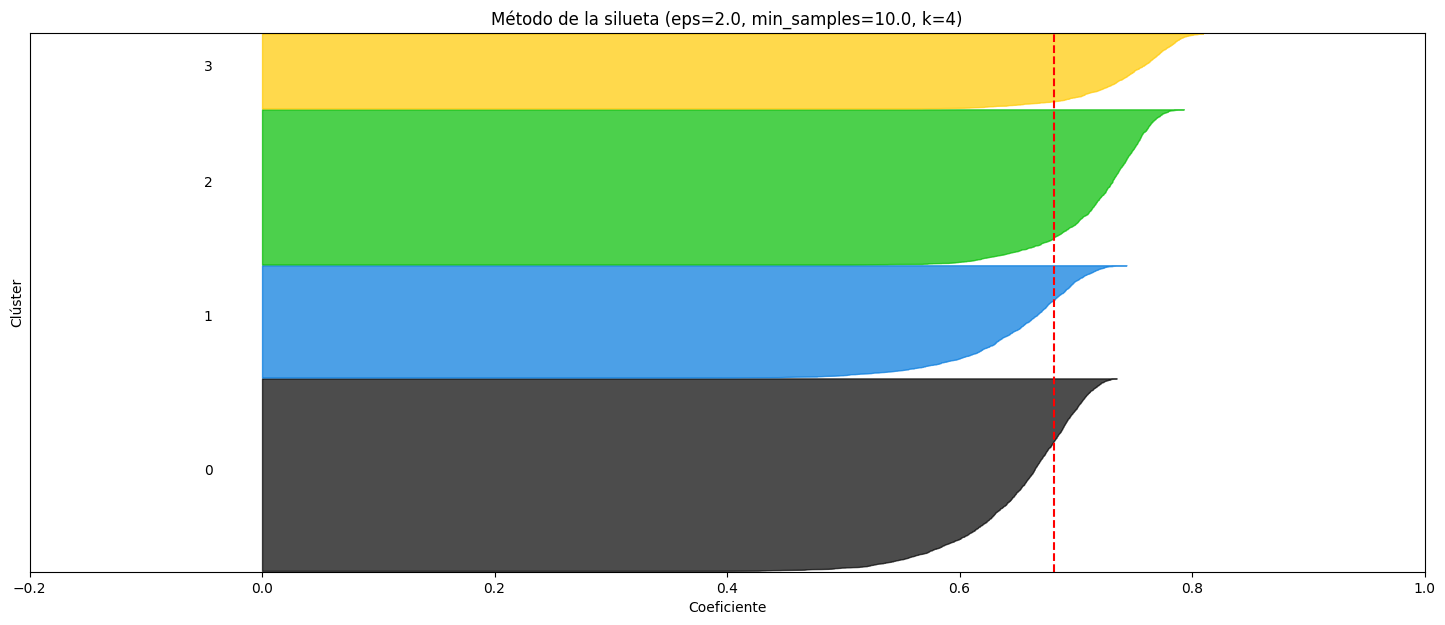

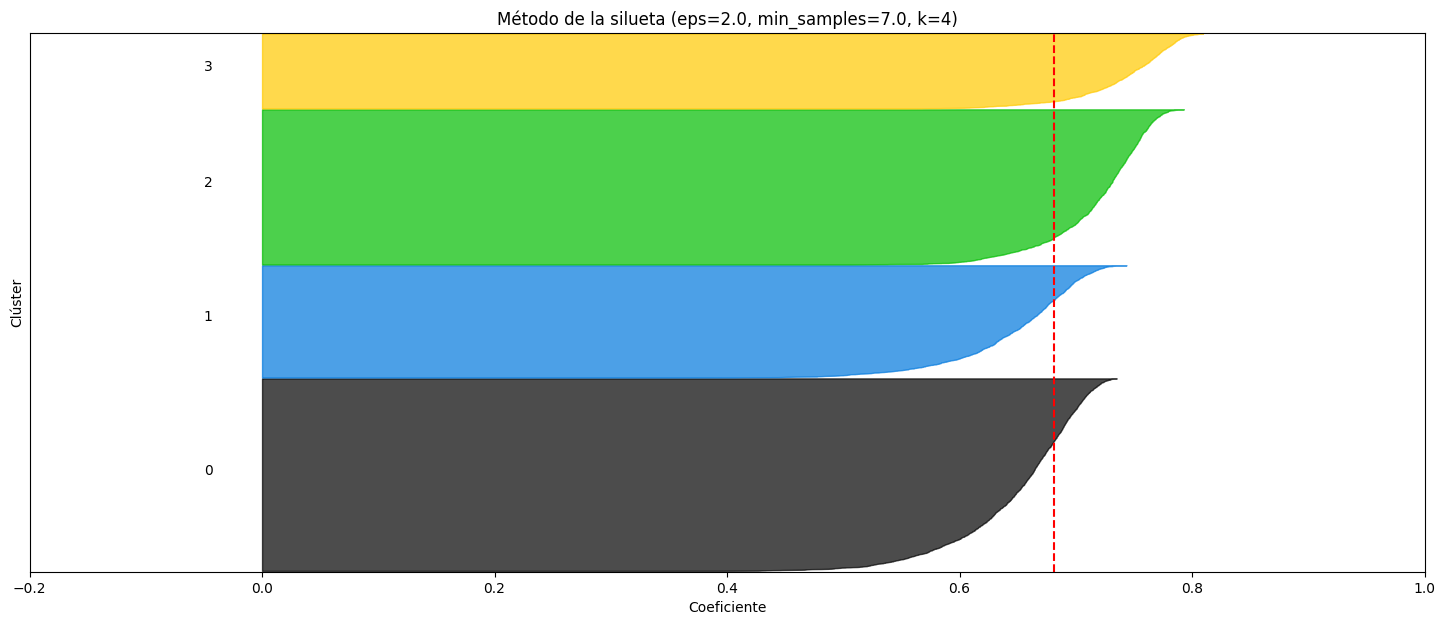

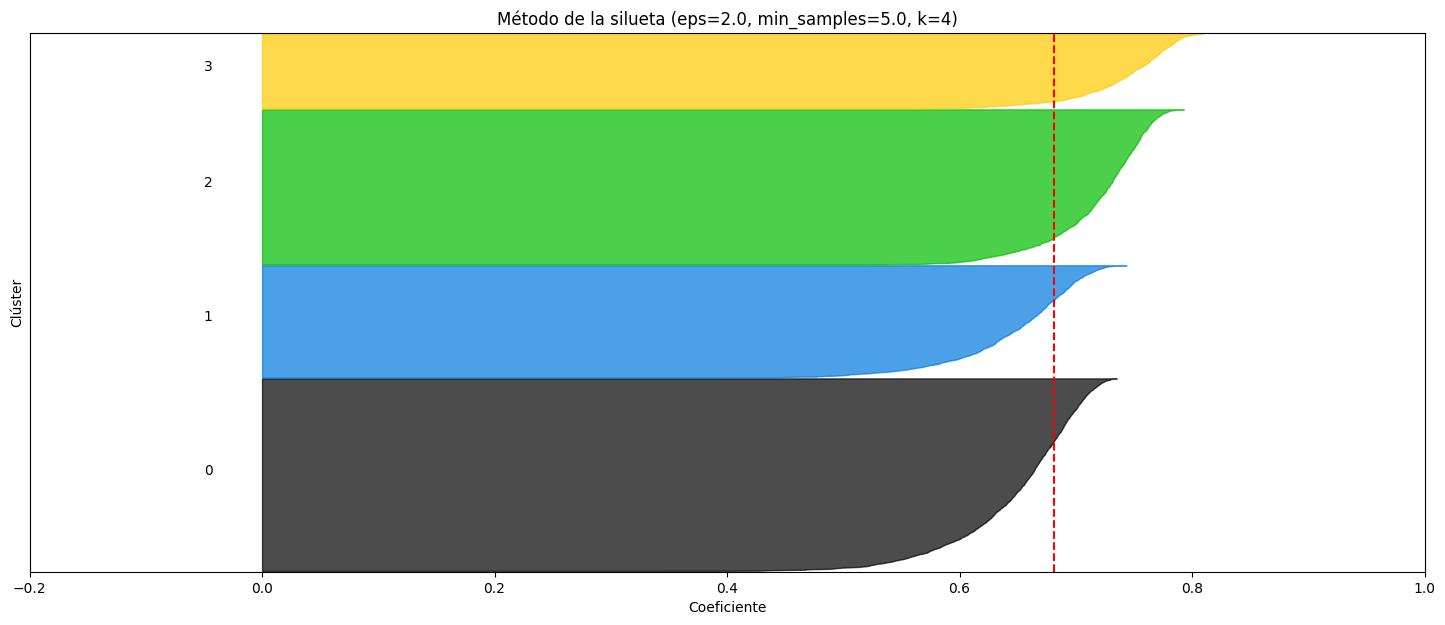

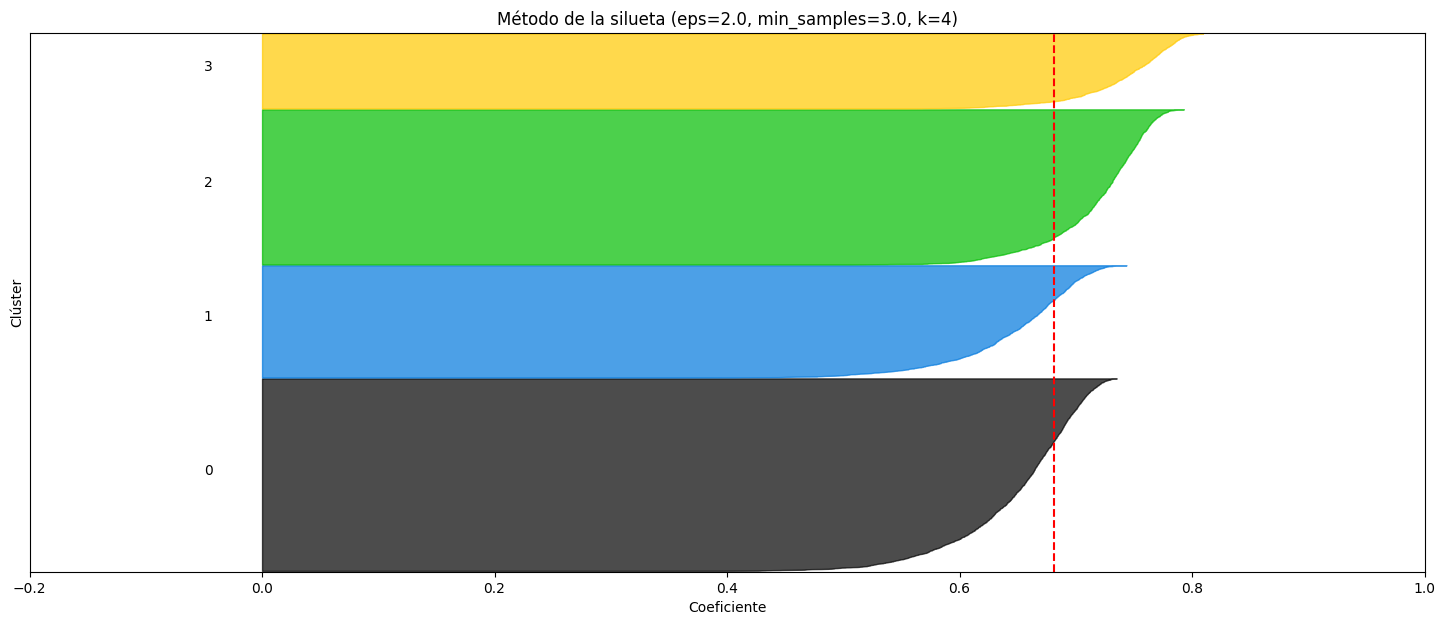

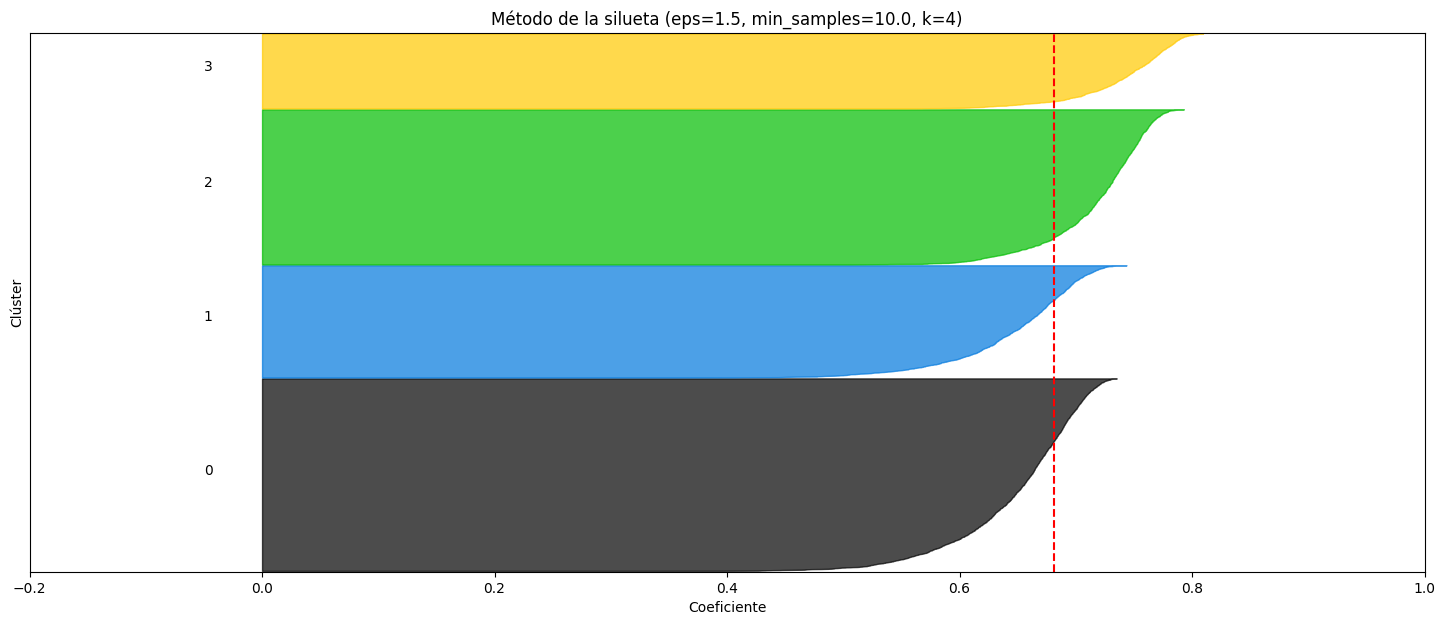

In [62]:
silhouette_analysis(data, silhouette_scores[:5], 'euclidean')

Como podemos ver, los tamaños de los clústeres y el comportamiento de cada ejemplo asignado a ellos es prácticamente idéntico para los cinco primeros casos. En general, los coeficientes son positivos para todos los datos y tienen un valor por encima de 0.5. Además, no tenemos puntos atípicos (identificados como el clúster con índice -1).

In [63]:
mejor_eps, mejor_min_samples, _, _= silhouette_scores.iloc[0]
model_DBSCAN = DBSCAN(eps=mejor_eps, min_samples=int(mejor_min_samples), metric='euclidean', n_jobs=-1)
model_DBSCAN.fit(data)

DBSCAN(eps=2.0, min_samples=10, n_jobs=-1)

([<matplotlib.axis.XTick at 0x7966c9cec980>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

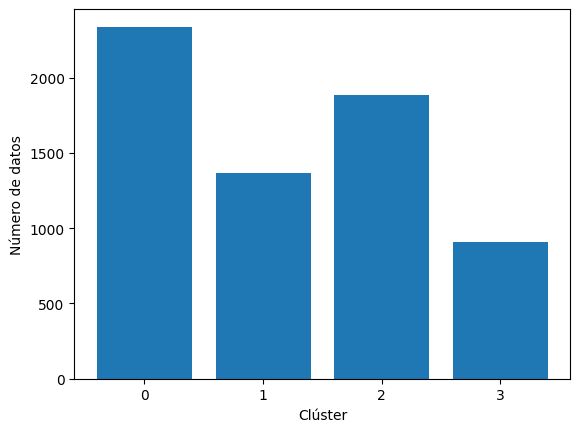

In [66]:
labels = model_DBSCAN.labels_
indexes, values = np.unique(labels, return_counts=True)

rects = plt.bar(indexes, values)
plt.xlabel('Clúster')
plt.ylabel('Número de datos')
plt.xticks(indexes)

In [68]:
# Utilizaremos las columnas de la variable data para construir un DataFrame
df_dbscan = pd.DataFrame(data, columns=data.columns)
# Si añadimos una columna con el resultado de la agrupación,
# podremos interpretar el resultado fácilmente
df_dbscan['cluster'] = model_DBSCAN.labels_
summary_df_dbscan = df_dbscan.groupby('cluster').mean()
summary_df_dbscan

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,0.139831,-0.689427,0.486514,0.828732,-0.691725,-0.597748,-1.084988,-0.911634,1.280662,-1.003939,0.342226
1,-0.353848,-0.024005,1.288322,0.812990,-1.022286,-0.306528,1.007019,1.323824,-0.580429,-0.281343,0.175598
2,1.067722,0.220141,-1.332504,-0.810863,0.797334,1.486911,0.953409,-0.439753,-0.896566,1.415150,0.477336
3,-2.039566,1.352269,-0.422846,-1.669951,1.659522,-1.082532,-0.694516,1.269350,-0.565529,0.072332,-2.131081


Mismos resultados que KMeans y agloremativo.

### **3. Preguntas**

1. ¿Con cual modelo se quedarían? Hay alguna forma de definir cuál es el mejor modelo para esta tarea de agrupación?
2. Modifica el rango de `silhouette_scores` que le damos a la función `silhouette_analysis()` para DBSCAN. ¿Qué sucede en los últimos cinco resultados?